# PM2.5 Prediction Using Neural Network Model (scikit-learn)

**Optimized with Optuna + TimeSeriesSplit Cross-Validation**

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import joblib
import time

In [3]:
# For hyperparameter tuning
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

In [4]:
# Setup paths
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    base_dir = notebook_dir.parent
else:
    base_dir = notebook_dir

output_dir = base_dir / 'preprocessed_data'
model_dir = base_dir / 'models'
model_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Data directory: {output_dir}")
print(f"Model directory: {model_dir}")

Base directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach
Data directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\preprocessed_data
Model directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\models


In [5]:
X_train = pd.read_csv(output_dir / 'X_train.csv', index_col=0, parse_dates=True) 
X_train.columns = X_train.columns.str.strip()  # Remove any leading/trailing whitespace from column names
print(X_train.columns)  # Remove any leading/trailing whitespace from column names

Index(['wind_kph', 'precip_mm', 'pressure_mb', 'humidity', 'cloud',
       'visibility_km', 'uv_index', 'air_quality_Nitrogen_dioxide',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Sulphur_dioxide', 'AOD', 'air_quality_PM10',
       'building_density', 'road_density_km', 'industrial_presence',
       'green_space_fraction', 'aod_pollution_interaction',
       'temp_pollution_interaction', 'pressure_pollution_interaction',
       'humidity_pollution_interaction', 'wind_gust_ratio',
       'uv_cloud_interaction', 'humidity_temp_interaction', 'pm25_lag1',
       'pollution_lag1', 'latitude', 'longitude', 'year', 'month', 'day',
       'dayofweek', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
       'wind_degree'],
      dtype='str')


In [6]:
# Load preprocessed data
X_train = pd.read_csv(output_dir / 'X_train.csv')
y_train = pd.read_csv(output_dir / 'y_train.csv').squeeze()
X_val = pd.read_csv(output_dir / 'X_val.csv')
y_val = pd.read_csv(output_dir / 'y_val.csv').squeeze()
X_test = pd.read_csv(output_dir / 'X_test.csv')
y_test = pd.read_csv(output_dir / 'y_test.csv').squeeze()

# Enforce final optimized feature set (aligned with the provided feature list).
# We support common column name aliases so the notebook works with the current preprocessed files.
desired_features = [
    'wind_kph', 'precip_mm', 'pressure_mb', 'humidity', 'cloud',
    'visibility_km', 'uv_index', 'air_quality_Nitrogen_dioxide',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Sulphur_dioxide',
    'AOD',
    'building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction',
    'aod_pollution_interaction', 'temp_pollution_interaction', 'pressure_pollution_interaction',
    'humidity_pollution_interaction', 'wind_gust_ratio', 'uv_cloud_interaction',
    'humidity_temp_interaction', 'pollution_lag1',
    'latitude', 'longitude', 'year', 'month', 'day', 'dayofweek',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'wind_degree'
]
# Define common aliases (key = desired name, value = list of possible column names in existing data)
aliases = {
    'air_quality_Nitrogen_dioxide': ['air_quality_Nitrogen_dioxide', 'NO2'],
    'air_quality_Carbon_Monoxide': ['air_quality_Carbon_Monoxide', 'CO'],
    'air_quality_Ozone': ['air_quality_Ozone', 'O3'],
    'humidity': ['humidity', 'relative_humidity'],
    'wind_degree': ['wind_degree', 'wind_deg', 'wind_direction'],
    'precip_mm': ['precip_mm', 'precipitation_mm'],
    'visibility_km': ['visibility_km', 'visibility'],
    'wind_kph': ['wind_kph', 'wind_kph', 'wind_mph'],
}

# Attempt to normalize/rename available columns to the desired names when aliases are found
applied = {}
for desired in desired_features:
    if desired in X_train.columns:
        applied[desired] = desired
        continue
    if desired in aliases:
        found = None
        for alt in aliases[desired]:
            if alt in X_train.columns:
                found = alt
                break
        if found:
            # rename in all splits so downstream code can rely on the desired name
            X_train = X_train.rename(columns={found: desired})
            X_val = X_val.rename(columns={found: desired})
            X_test = X_test.rename(columns={found: desired})
            applied[desired] = found

# Now build the final features list as the intersection of desired and available columns
final_features = [f for f in desired_features if f in X_train.columns]

# Report mapping and any missing features
print('Column aliases applied (desired <- source):')
for k, v in applied.items():
    print(f'  {k} <- {v}')
missing = [f for f in desired_features if f not in X_train.columns]
if missing:
    print('Warning - these desired features are missing from X_train and will be skipped:')
    print(missing)

# Subset datasets to the finalized feature set
X_train = X_train[final_features]
X_val = X_val[final_features]
X_test = X_test[final_features]




# Load scaling config
scaling_config = joblib.load(output_dir / 'scaling_config.pkl')

print(f"Training set:   {X_train.shape[0]:>6,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:>6,} samples, {X_val.shape[1]} features")
print(f"Test set:       {X_test.shape[0]:>6,} samples, {X_test.shape[1]} features")

print(f"\nFeatures: {list(X_train.columns)}")

# Data verification
print(f"\n{'='*80}")
print("DATA VERIFICATION")
print(f"{'='*80}")

print(f"\nFeature scaling check:")
print(f"  X_train mean: {X_train.mean().mean():.4f}, std: {X_train.std().mean():.4f}")
print(f"  X_val mean:   {X_val.mean().mean():.4f}, std: {X_val.std().mean():.4f}")
print(f"  X_test mean:  {X_test.mean().mean():.4f}, std: {X_test.std().mean():.4f}")

print(f"\nMissing values check:")
print(f"  X_train: {X_train.isnull().sum().sum()} missing")
print(f"  X_val:   {X_val.isnull().sum().sum()} missing")
print(f"  X_test:  {X_test.isnull().sum().sum()} missing")
print(f"  y_train: {y_train.isnull().sum()} missing")
print(f"  y_val:   {y_val.isnull().sum()} missing")
print(f"  y_test:  {y_test.isnull().sum()} missing")

print(f"\nTarget (pm25) statistics:")
print(f"  Train — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}, range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"  Val   — mean: {y_val.mean():.2f}, std: {y_val.std():.2f}, range: [{y_val.min():.2f}, {y_val.max():.2f}]")
print(f"  Test  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}, range: [{y_test.min():.2f}, {y_test.max():.2f}]")

# Check for outliers
print(f"\nOutlier check (values > 200 μg/m³):")
print(f"  Train: {(y_train > 200).sum()} outliers ({(y_train > 200).sum() / len(y_train) * 100:.2f}%)")
print(f"  Val:   {(y_val > 200).sum()} outliers ({(y_val > 200).sum() / len(y_val) * 100:.2f}%)")
print(f"  Test:  {(y_test > 200).sum()} outliers ({(y_test > 200).sum() / len(y_test) * 100:.2f}%)")
print(f"\n ")

Column aliases applied (desired <- source):
  wind_kph <- wind_kph
  precip_mm <- precip_mm
  pressure_mb <- pressure_mb
  humidity <- humidity
  cloud <- cloud
  visibility_km <- visibility_km
  uv_index <- uv_index
  air_quality_Nitrogen_dioxide <- air_quality_Nitrogen_dioxide
  air_quality_Carbon_Monoxide <- air_quality_Carbon_Monoxide
  air_quality_Ozone <- air_quality_Ozone
  air_quality_Sulphur_dioxide <- air_quality_Sulphur_dioxide
  AOD <- AOD
  building_density <- building_density
  road_density_km <- road_density_km
  industrial_presence <- industrial_presence
  green_space_fraction <- green_space_fraction
  aod_pollution_interaction <- aod_pollution_interaction
  temp_pollution_interaction <- temp_pollution_interaction
  pressure_pollution_interaction <- pressure_pollution_interaction
  humidity_pollution_interaction <- humidity_pollution_interaction
  wind_gust_ratio <- wind_gust_ratio
  uv_cloud_interaction <- uv_cloud_interaction
  humidity_temp_interaction <- humidity_te

``Note:`` 
- Outliers should be handled or removed in preprocessing for better model performance(we'll keep them for now but more investigation regarding them is needed)
- Selected only the needed features but this should be moved to the preprocessing notebook

## 2. Evaluation Metrics Function

In [7]:
def compute_metrics(y_true, y_pred, set_name=""):
    """Compute comprehensive regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
    }
    
    if set_name:
        print(f"{set_name} Set:")
        print(f"  MSE:  {mse:.4f}")
        print(f"  RMSE: {rmse:.4f} μg/m³")
        print(f"  MAE:  {mae:.4f} μg/m³")
        print(f"  R²:   {r2:.4f}")
    
    return metrics

print("Metrics function defined")

Metrics function defined


## 3. Hyperparameter Tuning with Optuna + TimeSeriesSplit

We'll use Optuna to find optimal hyperparameters using TimeSeriesSplit cross-validation on the training set.

In [8]:
# Optuna objective function
def objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    Uses TimeSeriesSplit CV on training data.
    """
    
    # Suggest hyperparameters
    hidden_layer_1 = trial.suggest_int('hidden_layer_1', 64, 256, step=32)
    hidden_layer_2 = trial.suggest_int('hidden_layer_2', 32, 128, step=16)
    hidden_layer_3 = trial.suggest_int('hidden_layer_3', 16, 64, step=16)
    
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    # Create model with suggested hyperparameters
    model = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_1, hidden_layer_2, hidden_layer_3),
        activation=activation,
        solver='adam',
        alpha=alpha,
        batch_size=batch_size,
        learning_rate='adaptive',
        learning_rate_init=learning_rate_init,
        max_iter=200,  # Reduced for faster tuning
        early_stopping=False,  # We'll use CV for validation
        random_state=42,
        verbose=False
    )
    
    # TimeSeriesSplit cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train on fold
        model.fit(X_fold_train, y_fold_train)
        
        # Evaluate on validation fold
        y_fold_pred = model.predict(X_fold_val)
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        cv_scores.append(fold_rmse)
    
    # Return mean CV RMSE (lower is better)
    mean_cv_rmse = np.mean(cv_scores)
    
    return mean_cv_rmse

print("Optuna objective function defined")
print("\nThis will perform TimeSeriesSplit CV (5 folds) for each trial")
print("Optimization metric: Mean CV RMSE (lower is better)")

Optuna objective function defined

This will perform TimeSeriesSplit CV (5 folds) for each trial
Optimization metric: Mean CV RMSE (lower is better)


In [9]:
# Create and run Optuna study
print(f"{'='*80}")
print("HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
print(f"{'='*80}")
print(f"\nSearching for optimal hyperparameters...")
print(f"This may take time depending on n_trials\n")

# Create study
study = optuna.create_study(
    direction='minimize',  # Minimize RMSE
    study_name='mlp_pm25_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
N_TRIALS = 10
start_time = time.time()

study.optimize(
    objective, 
    n_trials=N_TRIALS,
    show_progress_bar=True,
    n_jobs=1  
)

elapsed = time.time() - start_time

print(f"\n{'='*80}")
print(f"OPTIMIZATION COMPLETE")
print(f"{'='*80}")
print(f"Time elapsed: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Number of trials: {len(study.trials)}")
print(f"\nBest trial:")
print(f"  Value (CV RMSE): {study.best_value:.4f} μg/m³")
print(f"  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Save study
joblib.dump(study, model_dir / 'optuna_study.pkl')
print(f"\nStudy saved to {model_dir / 'optuna_study.pkl'}")


[I 2026-05-09 23:15:41,914] A new study created in memory with name: mlp_pm25_optimization


HYPERPARAMETER OPTIMIZATION WITH OPTUNA

Searching for optimal hyperparameters...
This may take time depending on n_trials



Best trial: 0. Best value: 26.4537:  10%|█         | 1/10 [09:55<1:29:20, 595.61s/it]

[I 2026-05-09 23:25:37,375] Trial 0 finished with value: 26.453734758745405 and parameters: {'hidden_layer_1': 128, 'hidden_layer_2': 128, 'hidden_layer_3': 48, 'activation': 'relu', 'alpha': 2.9375384576328295e-05, 'learning_rate_init': 0.00013066739238053285, 'batch_size': 64}. Best is trial 0 with value: 26.453734758745405.


Best trial: 0. Best value: 26.4537:  20%|██        | 2/10 [26:39<1:51:27, 835.88s/it]

...

[I 2026-05-10 00:14:11,190] Trial 7 finished with value: 32.7855041822249 and parameters: {'hidden_layer_1': 224, 'hidden_layer_2': 48, 'hidden_layer_3': 16, 'activation': 'relu', 'alpha': 0.0015382308040279, 'learning_rate_init': 0.0034877126245459306, 'batch_size': 128}. Best is trial 4 with value: 25.787936748051344.


Best trial: 4. Best value: 25.7879:  90%|█████████ | 9/10 [59:23<04:01, 241.73s/it]

[I 2026-05-10 00:15:05,233] Trial 8 finished with value: 38.968656708157724 and parameters: {'hidden_layer_1': 256, 'hidden_layer_2': 96, 'hidden_layer_3': 32, 'activation': 'tanh', 'alpha': 9.452571391072311e-05, 'learning_rate_init': 0.002878805718308925, 'batch_size': 128}. Best is trial 4 with value: 25.787936748051344.


Best trial: 4. Best value: 25.7879: 100%|██████████| 10/10 [1:00:51<00:00, 365.11s/it]

[I 2026-05-10 00:16:32,975] Trial 9 finished with value: 32.88328094768143 and parameters: {'hidden_layer_1': 64, 'hidden_layer_2': 96, 'hidden_layer_3': 64, 'activation': 'tanh', 'alpha': 0.00030296104428212476, 'learning_rate_init': 0.0011103647313054626, 'batch_size': 64}. Best is trial 4 with value: 25.787936748051344.

OPTIMIZATION COMPLETE
Time elapsed: 3651.1s (60.9 min)
Number of trials: 10

Best trial:
  Value (CV RMSE): 25.7879 μg/m³
  Params:
    hidden_layer_1: 64
    hidden_layer_2: 80
    hidden_layer_3: 16
    activation: relu
    alpha: 0.0009717775305059633
    learning_rate_init: 0.0004201672054372534
    batch_size: 128

Study saved to c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\models\optuna_study.pkl


## 4. Train Final Model with Best Hyperparameters

### Alternative: Train Quick Model with Basic Parameters
Run this cell if you want to skip the hyperparameter tuning process above.
(this would be removed later once the best parameters are found)

In [12]:
print(f"{'='*80}")
print("TRAINING MODEL WITH BASIC HYPERPARAMETERS")
print(f"{'='*80}")

# Create model with sensible default parameters
basic_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-5,
    random_state=42,
    verbose=True
)

print("\nModel architecture:")
print("  Hidden layers: (128, 64, 32)")
print("  Activation: relu")
print("  Alpha (L2): 0.001")
print("  Learning rate: 0.001")
print("  Batch size: 128")

print(f"\n{'='*60}")
print("Starting training on full training set...")
print(f"{'='*60}\n")

start_time = time.time()
basic_model.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'='*60}")
print(f"Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Iterations: {basic_model.n_iter_}")
print(f"Best validation score: {basic_model.best_validation_score_:.4f}")
print(f"Final training loss: {basic_model.loss_:.6f}")
print(f"{'='*60}")

# Map to final_model so down-stream evaluation cells work properly!
final_model = basic_model


TRAINING MODEL WITH BASIC HYPERPARAMETERS

Model architecture:
  Hidden layers: (128, 64, 32)
  Activation: relu
  Alpha (L2): 0.001
  Learning rate: 0.001
  Batch size: 128

Starting training on full training set...

Iteration 1, loss = 629.60812045
Validation score: 0.397785
Iteration 2, loss = 490.18439039
Validation score: 0.413995
Iteration 3, loss = 465.72669469
Validation score: 0.438209
Iteration 4, loss = 437.16518889
Validation score: 0.451960
Iteration 5, loss = 400.32784973
Validation score: 0.522022
Iteration 6, loss = 387.37774488
Validation score: 0.574609
Iteration 7, loss = 364.55074311
Validation score: 0.502348
Iteration 8, loss = 339.53144108
Validation score: 0.628868
Iteration 9, loss = 331.61077512
Validation score: 0.608504
Iteration 10, loss = 319.20492159
Validation score: 0.642874
Iteration 11, loss = 318.99655575
Validation score: 0.653741
Iteration 12, loss = 312.33713848
Validation score: 0.624339
Iteration 13, loss = 304.41904425
Validation score: 0.66508

## This uses optuna results

- Run this to load the optuna results

In [13]:
study = joblib.load('../models/optuna_study.pkl')
best_params = study.best_params 


In [14]:
# Extract best hyperparameters
best_params = study.best_params

print(f"{'='*80}")
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print(f"{'='*80}")

# Create final model
final_model = MLPRegressor(
    hidden_layer_sizes=(
        best_params['hidden_layer_1'],
        best_params['hidden_layer_2'],
        best_params['hidden_layer_3']
    ),
    activation=best_params['activation'],
    solver='adam',
    alpha=best_params['alpha'],
    batch_size=best_params['batch_size'],
    learning_rate='adaptive',
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-5,
    random_state=42,
    verbose=True
)

print(f"\nModel architecture:")
print(f"  Hidden layers: ({best_params['hidden_layer_1']}, {best_params['hidden_layer_2']}, {best_params['hidden_layer_3']})")
print(f"  Activation: {best_params['activation']}")
print(f"  Alpha (L2): {best_params['alpha']:.6f}")
print(f"  Learning rate: {best_params['learning_rate_init']:.6f}")
print(f"  Batch size: {best_params['batch_size']}")

print(f"\n{'='*60}")
print("Starting training on full training set...")
print(f"{'='*60}\n")

start_time = time.time()
final_model.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'='*60}")
print(f"Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Iterations: {final_model.n_iter_}")
print(f"Best validation score: {final_model.best_validation_score_:.4f}")
print(f"Final training loss: {final_model.loss_:.6f}")
print(f"{'='*60}")


TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Model architecture:
  Hidden layers: (64, 80, 16)
  Activation: relu
  Alpha (L2): 0.000972
  Learning rate: 0.000420
  Batch size: 128

Starting training on full training set...

Iteration 1, loss = 766.77158195
Validation score: 0.184781
Iteration 2, loss = 531.52489448
Validation score: 0.399011
Iteration 3, loss = 465.54061032
Validation score: 0.429709
Iteration 4, loss = 444.84194794
Validation score: 0.441166
Iteration 5, loss = 440.06743558
Validation score: 0.453188
Iteration 6, loss = 432.08515631
Validation score: 0.463653
Iteration 7, loss = 420.16851727
Validation score: 0.476970
Iteration 8, loss = 408.11817512
Validation score: 0.496686
Iteration 9, loss = 399.45943428
Validation score: 0.502065
Iteration 10, loss = 390.50216158
Validation score: 0.530044
Iteration 11, loss = 381.67263619
Validation score: 0.533304
Iteration 12, loss = 369.18245653
Validation score: 0.551687
Iteration 13, loss = 360.90844975
Validation scor

## 5. Model Evaluation on All Splits

In [15]:
#Generate predictions
train_pred = final_model.predict(X_train)
val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

print(f"{'='*80}")
print("MODEL EVALUATION RESULTS")
print(f"{'='*80}\n")

results = {}
results['Train'] = compute_metrics(y_train.values, train_pred, "Train")
print()
results['Validation'] = compute_metrics(y_val.values, val_pred, "Validation")
print()
results['Test'] = compute_metrics(y_test.values, test_pred, "Test")

results_df = pd.DataFrame(results).T
print(f"\n{'='*80}")
print("\nSummary Table:")
print(results_df.to_string())
print(f"\n{'='*80}")

print("\nPerformance Check:")
if results['Train']['R²'] > results['Validation']['R²'] > results['Test']['R²']:
    print("GOOD: Train R² > Val R² > Test R² (expected pattern)")
elif results['Train']['R²'] > results['Test']['R²'] and results['Validation']['R²'] > results['Test']['R²']:
    print("OK: Train & Val R² > Test R² (acceptable)")
else:
    print(f"WARNING: Unexpected R² pattern")
    print(f"Train: {results['Train']['R²']:.4f}, Validation: {results['Validation']['R²']:.4f}, Test: {results['Test']['R²']:.4f}")


MODEL EVALUATION RESULTS

Train Set:
  MSE:  293.4394
  RMSE: 17.1301 μg/m³
  MAE:  9.3498 μg/m³
  R²:   0.8279

Validation Set:
  MSE:  307.4436
  RMSE: 17.5341 μg/m³
  MAE:  9.3258 μg/m³
  R²:   0.4190

Test Set:
  MSE:  385.7327
  RMSE: 19.6401 μg/m³
  MAE:  10.5143 μg/m³
  R²:   0.4300


Summary Table:
                   MSE       RMSE        MAE        R²
Train       293.439415  17.130073   9.349833  0.827940
Validation  307.443636  17.534071   9.325829  0.418954
Test        385.732678  19.640078  10.514345  0.430017


Performance Check:
Train: 0.8279, Validation: 0.4190, Test: 0.4300


## 6. Prediction Visualizations

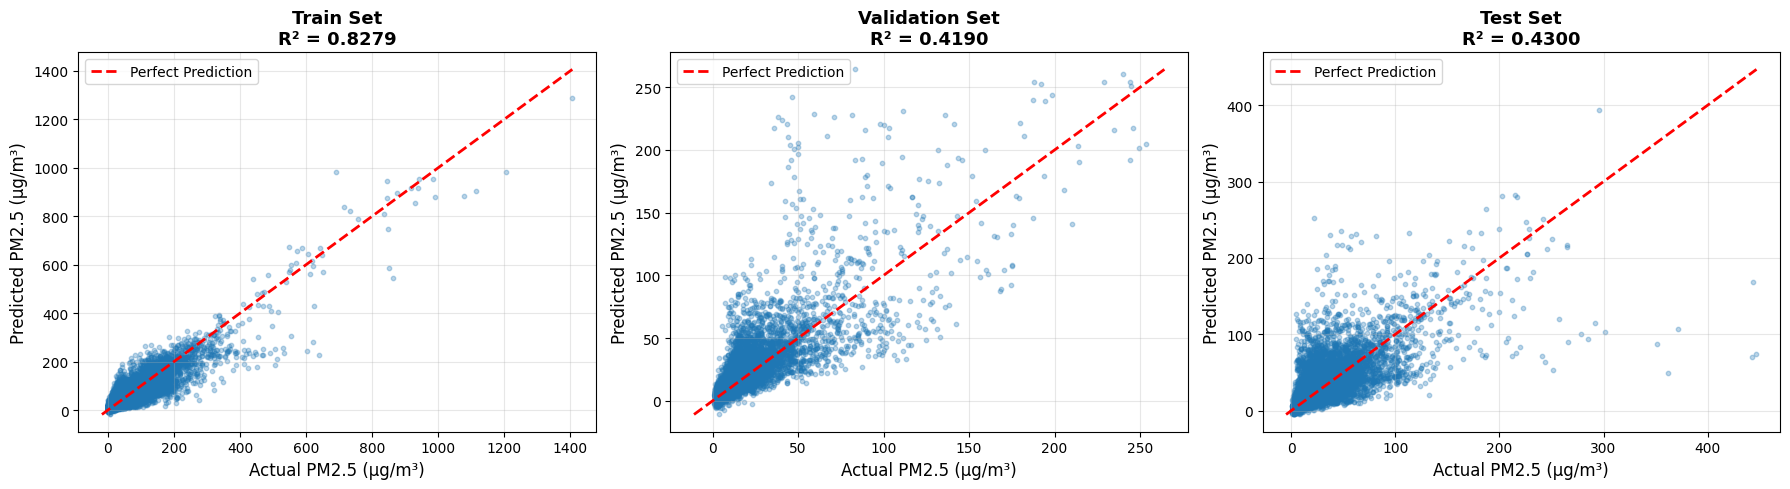

In [16]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Validation', y_val.values, val_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual PM2.5 (μg/m³)', fontsize=12)
    ax.set_ylabel('Predicted PM2.5 (μg/m³)', fontsize=12)
    ax.set_title(f'{name} Set\nR² = {results[name]["R²"]:.4f}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(model_dir / 'predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


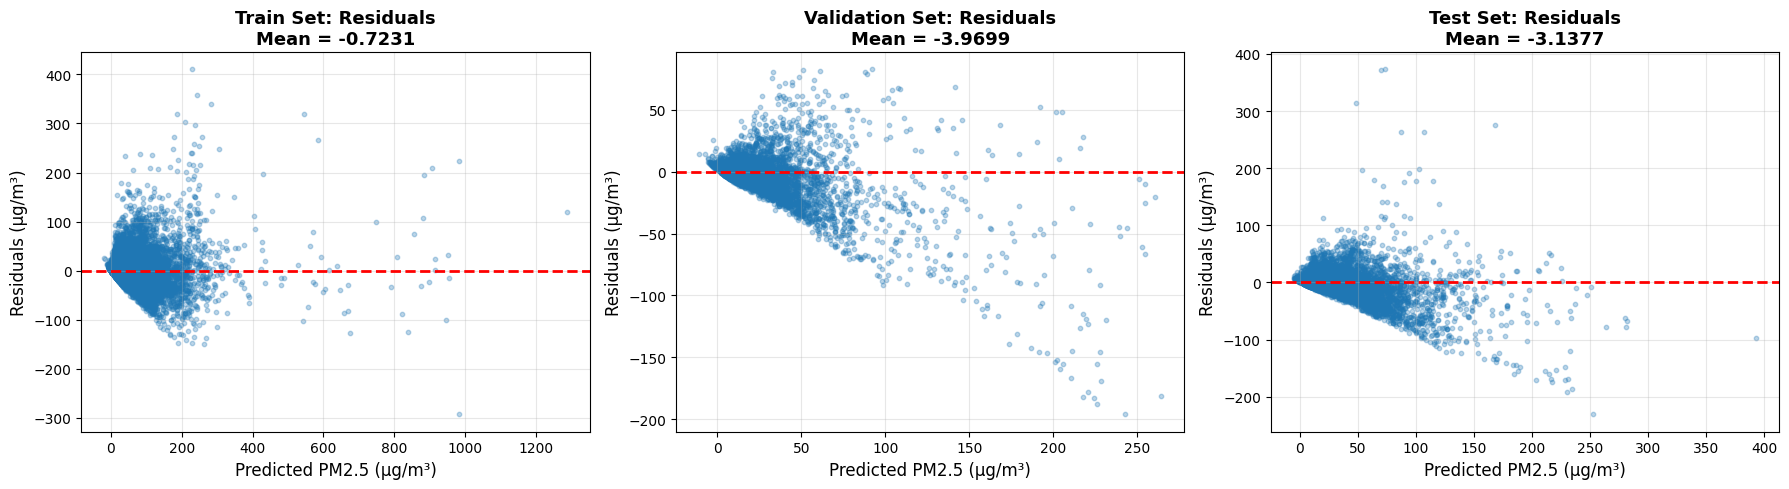

In [17]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Validation', y_val.values, val_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    residuals = y_true - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    
    ax.set_xlabel('Predicted PM2.5 (μg/m³)', fontsize=12)
    ax.set_ylabel('Residuals (μg/m³)', fontsize=12)
    ax.set_title(f'{name} Set: Residuals\nMean = {residuals.mean():.4f}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(model_dir / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()


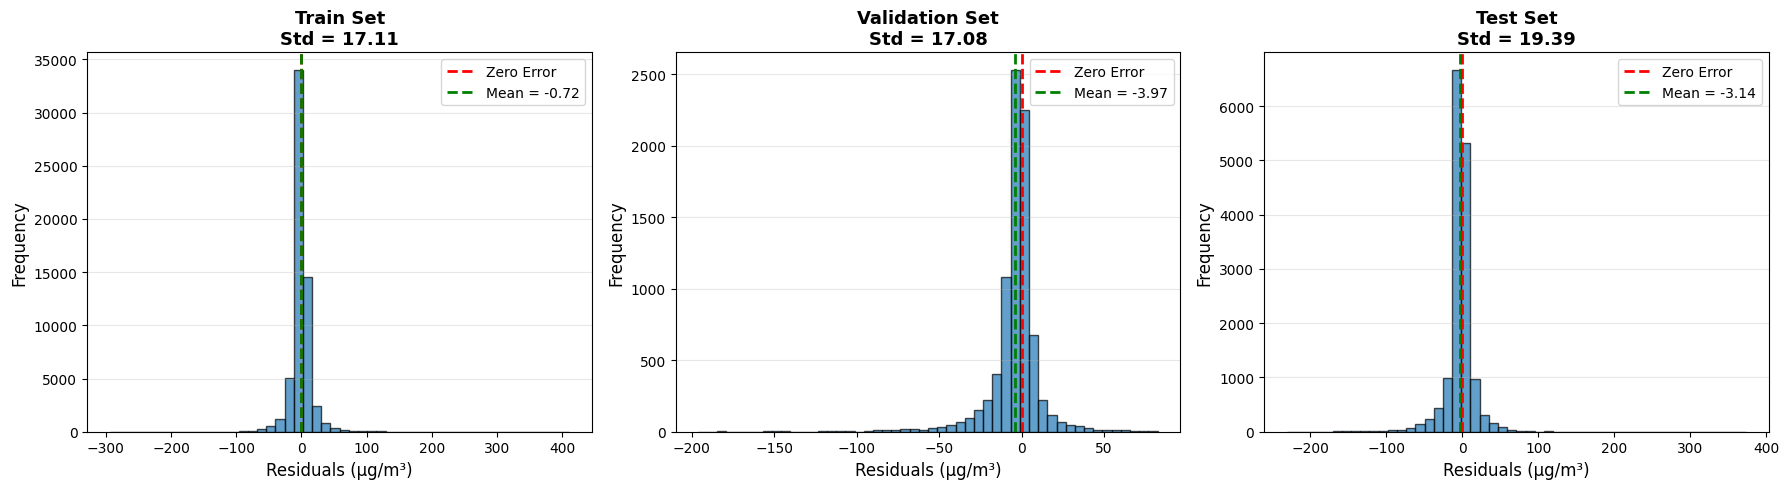

In [18]:
# Error distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Validation', y_val.values, val_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    residuals = y_true - y_pred
    
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
    ax.axvline(x=residuals.mean(), color='g', linestyle='--', lw=2, label=f'Mean = {residuals.mean():.2f}')
    
    ax.set_xlabel('Residuals (μg/m³)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{name} Set\nStd = {residuals.std():.2f}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(model_dir / 'error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Final Cross-Validation Assessment

### Alternative: Final CV with Basic Parameters
Run this cell to perform the 5-fold TimeSeries split evaluation using the standard baseline parameters(will be removed later)

In [19]:
# Final CV with basic params
print(f"{'='*80}")
print("FINAL CROSS-VALIDATION WITH BASIC HYPERPARAMETERS")
print(f"{'='*80}")
print("\nPerforming TimeSeriesSplit CV (5 folds)...\n")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {
    'fold': [], 'train_size': [], 'val_size': [],
    'train_r2': [], 'val_r2': [], 'train_rmse': [], 'val_rmse': [],
    'train_mae': [], 'val_mae': []
}

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Using hardcoded basic parameters
    fold_model = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=128,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=False,
        random_state=42,
        verbose=False
    )
    
    fold_model.fit(X_fold_train, y_fold_train)
    
    train_pred_fold = fold_model.predict(X_fold_train)
    val_pred_fold = fold_model.predict(X_fold_val)
    
    train_r2 = r2_score(y_fold_train, train_pred_fold)
    val_r2 = r2_score(y_fold_val, val_pred_fold)
    train_rmse = np.sqrt(mean_squared_error(y_fold_train, train_pred_fold))
    val_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred_fold))
    train_mae = mean_absolute_error(y_fold_train, train_pred_fold)
    val_mae = mean_absolute_error(y_fold_val, val_pred_fold)
    
    cv_results['fold'].append(fold_idx)
    cv_results['train_size'].append(len(train_idx))
    cv_results['val_size'].append(len(val_idx))
    cv_results['train_r2'].append(train_r2)
    cv_results['val_r2'].append(val_r2)
    cv_results['train_rmse'].append(train_rmse)
    cv_results['val_rmse'].append(val_rmse)
    cv_results['train_mae'].append(train_mae)
    cv_results['val_mae'].append(val_mae)
    
    print(f"Fold {fold_idx}:")
    print(f"  Train: {len(train_idx):>6} samples | R²={train_r2:>6.4f} | RMSE={train_rmse:>7.4f} | MAE={train_mae:>6.4f}")
    print(f"  Val:   {len(val_idx):>6} samples | R²={val_r2:>6.4f} | RMSE={val_rmse:>7.4f} | MAE={val_mae:>6.4f}")
    print()

cv_df = pd.DataFrame(cv_results)

print(f"{'='*80}")
print("CROSS-VALIDATION SUMMARY (BASIC MODEL)")
print(f"{'='*80}")
print(f"\nValidation Metrics (Mean ± Std):")
print(f"  R²:   {cv_df['val_r2'].mean():.4f} ± {cv_df['val_r2'].std():.4f}")
print(f"  RMSE: {cv_df['val_rmse'].mean():.4f} ± {cv_df['val_rmse'].std():.4f} μg/m³")
print(f"  MAE:  {cv_df['val_mae'].mean():.4f} ± {cv_df['val_mae'].std():.4f} μg/m³")

print(f"\nStability Check:")
if cv_df['val_r2'].std() < 0.1:
    print(f"GOOD: Low variance (std = {cv_df['val_r2'].std():.4f})")
else:
    print(f"WARNING: High variance (std = {cv_df['val_r2'].std():.4f})")

cv_df.to_csv(model_dir / 'cv_results.csv', index=False)
print(f"\nCV results saved")


FINAL CROSS-VALIDATION WITH BASIC HYPERPARAMETERS

Performing TimeSeriesSplit CV (5 folds)...

Fold 1:
  Train:   9974 samples | R²=0.9096 | RMSE=15.5224 | MAE=7.1071
  Val:     9970 samples | R²=0.5800 | RMSE=21.8571 | MAE=11.0565

Fold 2:
  Train:  19944 samples | R²=0.9278 | RMSE=11.7432 | MAE=6.1614
  Val:     9970 samples | R²=0.4649 | RMSE=33.0414 | MAE=16.5995

Fold 3:
  Train:  29914 samples | R²=0.8966 | RMSE=14.5015 | MAE=7.9628
  Val:     9970 samples | R²=-0.8368 | RMSE=53.2619 | MAE=14.2816

Fold 4:
  Train:  39884 samples | R²=0.8666 | RMSE=16.0592 | MAE=9.6740
  Val:     9970 samples | R²=0.5696 | RMSE=23.8934 | MAE=11.1727

Fold 5:
  Train:  49854 samples | R²=0.8543 | RMSE=16.2461 | MAE=8.8751
  Val:     9970 samples | R²=0.7476 | RMSE=17.2039 | MAE=9.0374

CROSS-VALIDATION SUMMARY (BASIC MODEL)

Validation Metrics (Mean ± Std):
  R²:   0.3051 ± 0.6463
  RMSE: 29.8515 ± 14.2968 μg/m³
  MAE:  12.4295 ± 2.9912 μg/m³

Stability Check:

CV results saved


### This uses the best parameters found by optuna

In [20]:
# Final CV with best params
print(f"{'='*80}")
print("FINAL CROSS-VALIDATION WITH BEST HYPERPARAMETERS")
print(f"{'='*80}")
print("\nPerforming TimeSeriesSplit CV (5 folds)...\n")

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {
    'fold': [], 'train_size': [], 'val_size': [],
    'train_r2': [], 'val_r2': [], 'train_rmse': [], 'val_rmse': [],
    'train_mae': [], 'val_mae': []
}

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    fold_model = MLPRegressor(
        hidden_layer_sizes=(best_params['hidden_layer_1'], best_params['hidden_layer_2'], best_params['hidden_layer_3']),
        activation=best_params['activation'],
        solver='adam',
        alpha=best_params['alpha'],
        batch_size=best_params['batch_size'],
        learning_rate='adaptive',
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=200,
        early_stopping=False,
        random_state=42,
        verbose=False
    )
    
    fold_model.fit(X_fold_train, y_fold_train)
    
    train_pred_fold = fold_model.predict(X_fold_train)
    val_pred_fold = fold_model.predict(X_fold_val)
    
    train_r2 = r2_score(y_fold_train, train_pred_fold)
    val_r2 = r2_score(y_fold_val, val_pred_fold)
    train_rmse = np.sqrt(mean_squared_error(y_fold_train, train_pred_fold))
    val_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred_fold))
    train_mae = mean_absolute_error(y_fold_train, train_pred_fold)
    val_mae = mean_absolute_error(y_fold_val, val_pred_fold)
    
    cv_results['fold'].append(fold_idx)
    cv_results['train_size'].append(len(train_idx))
    cv_results['val_size'].append(len(val_idx))
    cv_results['train_r2'].append(train_r2)
    cv_results['val_r2'].append(val_r2)
    cv_results['train_rmse'].append(train_rmse)
    cv_results['val_rmse'].append(val_rmse)
    cv_results['train_mae'].append(train_mae)
    cv_results['val_mae'].append(val_mae)
    
    print(f"Fold {fold_idx}:")
    print(f"  Train: {len(train_idx):>6} samples | R²={train_r2:>6.4f} | RMSE={train_rmse:>7.4f} | MAE={train_mae:>6.4f}")
    print(f"  Val:   {len(val_idx):>6} samples | R²={val_r2:>6.4f} | RMSE={val_rmse:>7.4f} | MAE={val_mae:>6.4f}")
    print()

cv_df = pd.DataFrame(cv_results)

print(f"{'='*80}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*80}")
print(f"\nValidation Metrics (Mean ± Std):")
print(f"  R²:   {cv_df['val_r2'].mean():.4f} ± {cv_df['val_r2'].std():.4f}")
print(f"  RMSE: {cv_df['val_rmse'].mean():.4f} ± {cv_df['val_rmse'].std():.4f} μg/m³")
print(f"  MAE:  {cv_df['val_mae'].mean():.4f} ± {cv_df['val_mae'].std():.4f} μg/m³")

print(f"\nStability Check:")
if cv_df['val_r2'].std() < 0.1:
    print(f"GOOD: Low variance (std = {cv_df['val_r2'].std():.4f})")
else:
    print(f"WARNING: High variance (std = {cv_df['val_r2'].std():.4f})")

cv_df.to_csv(model_dir / 'cv_results.csv', index=False)
print(f"\nCV results saved")


FINAL CROSS-VALIDATION WITH BEST HYPERPARAMETERS

Performing TimeSeriesSplit CV (5 folds)...

Fold 1:
  Train:   9974 samples | R²=0.9170 | RMSE=14.8699 | MAE=7.7225
  Val:     9970 samples | R²=0.6113 | RMSE=21.0280 | MAE=11.5333

Fold 2:
  Train:  19944 samples | R²=0.8811 | RMSE=15.0702 | MAE=7.7200
  Val:     9970 samples | R²=0.3862 | RMSE=35.3896 | MAE=19.4884

Fold 3:
  Train:  29914 samples | R²=0.7989 | RMSE=20.2241 | MAE=12.9995
  Val:     9970 samples | R²=0.4246 | RMSE=29.8109 | MAE=14.5580

Fold 4:
  Train:  39884 samples | R²=0.8083 | RMSE=19.2480 | MAE=11.8101
  Val:     9970 samples | R²=0.5274 | RMSE=25.0378 | MAE=12.1546

Fold 5:
  Train:  49854 samples | R²=0.8107 | RMSE=18.5199 | MAE=10.2616
  Val:     9970 samples | R²=0.7337 | RMSE=17.6734 | MAE=9.5023

CROSS-VALIDATION SUMMARY

Validation Metrics (Mean ± Std):
  R²:   0.5366 ± 0.1411
  RMSE: 25.7879 ± 7.0257 μg/m³
  MAE:  13.4473 ± 3.8284 μg/m³

Stability Check:

CV results saved


# Feature importance

Calculating Permutation Feature Importance (this might take a few seconds)...


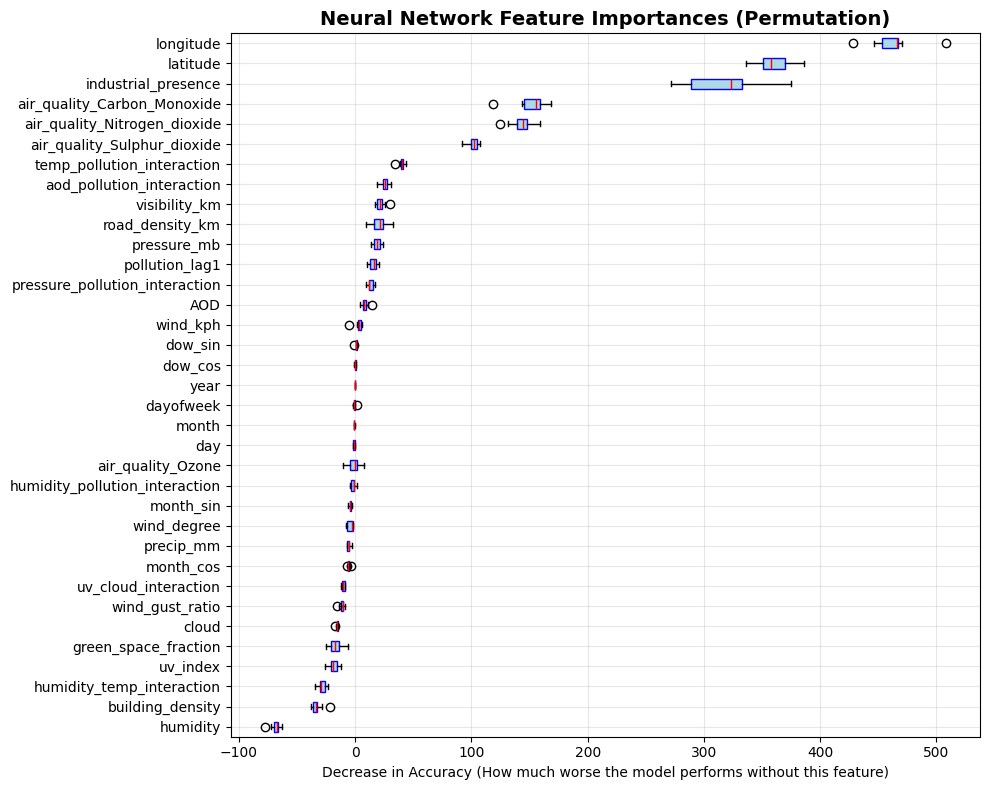

In [21]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

print("Calculating Permutation Feature Importance (this might take a few seconds)...")

# Calculate importance on the validation set
result = permutation_importance(
    final_model, 
    X_val, 
    y_val, 
    n_repeats=10,       # Shuffles each feature 10 times to get a stable average
    random_state=42, 
    n_jobs=-1,          # Uses all your CPU cores to make it fast
    scoring='neg_mean_squared_error' # We look at how much the error increases
)

# Sort the features by how important they are
sorted_idx = result.importances_mean.argsort()

# Create a nice plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=X_val.columns[sorted_idx],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red')
)

ax.set_title("Neural Network Feature Importances (Permutation)", fontsize=14, fontweight='bold')
ax.set_xlabel("Decrease in Accuracy (How much worse the model performs without this feature)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig(model_dir / 'nn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


- The result of the plot shows exactly why the neural network performance is not realy at its best since the pm25_lag1 dominates the other features and the models learned to use the previous value of the pm25_lag1 to predict the current one

In [22]:

# We use the 'result' object generated by the permutation_importance cell above.
mean_importances = result.importances_mean
# Some importances might be slightly negative due to random chance (meaning the model didn't use them). 
# We clip negatives to 0 so out percentages make mathematical sense.
positive_importances = np.maximum(mean_importances, 0)
# Calculate the percentages
total_importance = positive_importances.sum()
if total_importance > 0:
    percentages = (positive_importances / total_importance) * 100
else:
    percentages = np.zeros_like(positive_importances)
# Build a DataFrame for easy sorting and display
importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Percentage (%)': percentages
})
# Sort from highest importance to lowest
importance_df = importance_df.sort_values(by='Percentage (%)', ascending=False).reset_index(drop=True)
# Print a nicely formatted table
print("FEATURE IMPORTANCE PERCENTAGES")
print("="*45)
for _, row in importance_df.iterrows():
    # Print out any feature that contributes at least 0.01%
    if row['Percentage (%)'] >= 0.01:
        print(f"{row['Feature']:<35} {row['Percentage (%)']:>6.2f}%")
print("="*45)
print(f"{'TOTAL':<35} 100.00%")

FEATURE IMPORTANCE PERCENTAGES
longitude                            27.24%
latitude                             21.11%
industrial_presence                  18.58%
air_quality_Carbon_Monoxide           8.92%
air_quality_Nitrogen_dioxide          8.39%
air_quality_Sulphur_dioxide           5.98%
temp_pollution_interaction            2.35%
aod_pollution_interaction             1.49%
visibility_km                         1.26%
road_density_km                       1.21%
pressure_mb                           1.10%
pollution_lag1                        0.91%
pressure_pollution_interaction        0.76%
AOD                                   0.47%
wind_kph                              0.17%
dow_sin                               0.05%
TOTAL                               100.00%


## 8. Save Model & Results

In [23]:
# Save model
joblib.dump(final_model, model_dir / 'best_pm25_mlp_model.pkl')
print(f"Model saved to {model_dir / 'best_pm25_mlp_model.pkl'}")

# Save results
results_df.to_csv(model_dir / 'model_performance.csv')
print(f"Results saved to {model_dir / 'model_performance.csv'}")

# Model info
n_params = sum(w.size for w in final_model.coefs_) + sum(b.size for b in final_model.intercepts_)
print(f"\nModel Summary:")
print(f"  Total parameters: {n_params:,}")
print(f"  Architecture: {final_model.hidden_layer_sizes}")
print(f"  Best CV RMSE: {study.best_value:.4f} μg/m³")
print(f"  Test RMSE: {results['Test']['RMSE']:.4f} μg/m³")
print(f"  Test R²: {results['Test']['R²']:.4f}")


Model saved to c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\models\best_pm25_mlp_model.pkl
Results saved to c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\Global_approach\models\model_performance.csv

Model Summary:
  Total parameters: 8,817
  Architecture: (64, 80, 16)
  Best CV RMSE: 25.7879 μg/m³
  Test RMSE: 19.6401 μg/m³
  Test R²: 0.4300
